Paired t-test: Tone+Trace vs ITI
t-statistic: 0.6529
p-value: 0.5604
Mean difference: 1.1697 ± 1.7915 cm/s
n = 4 mice


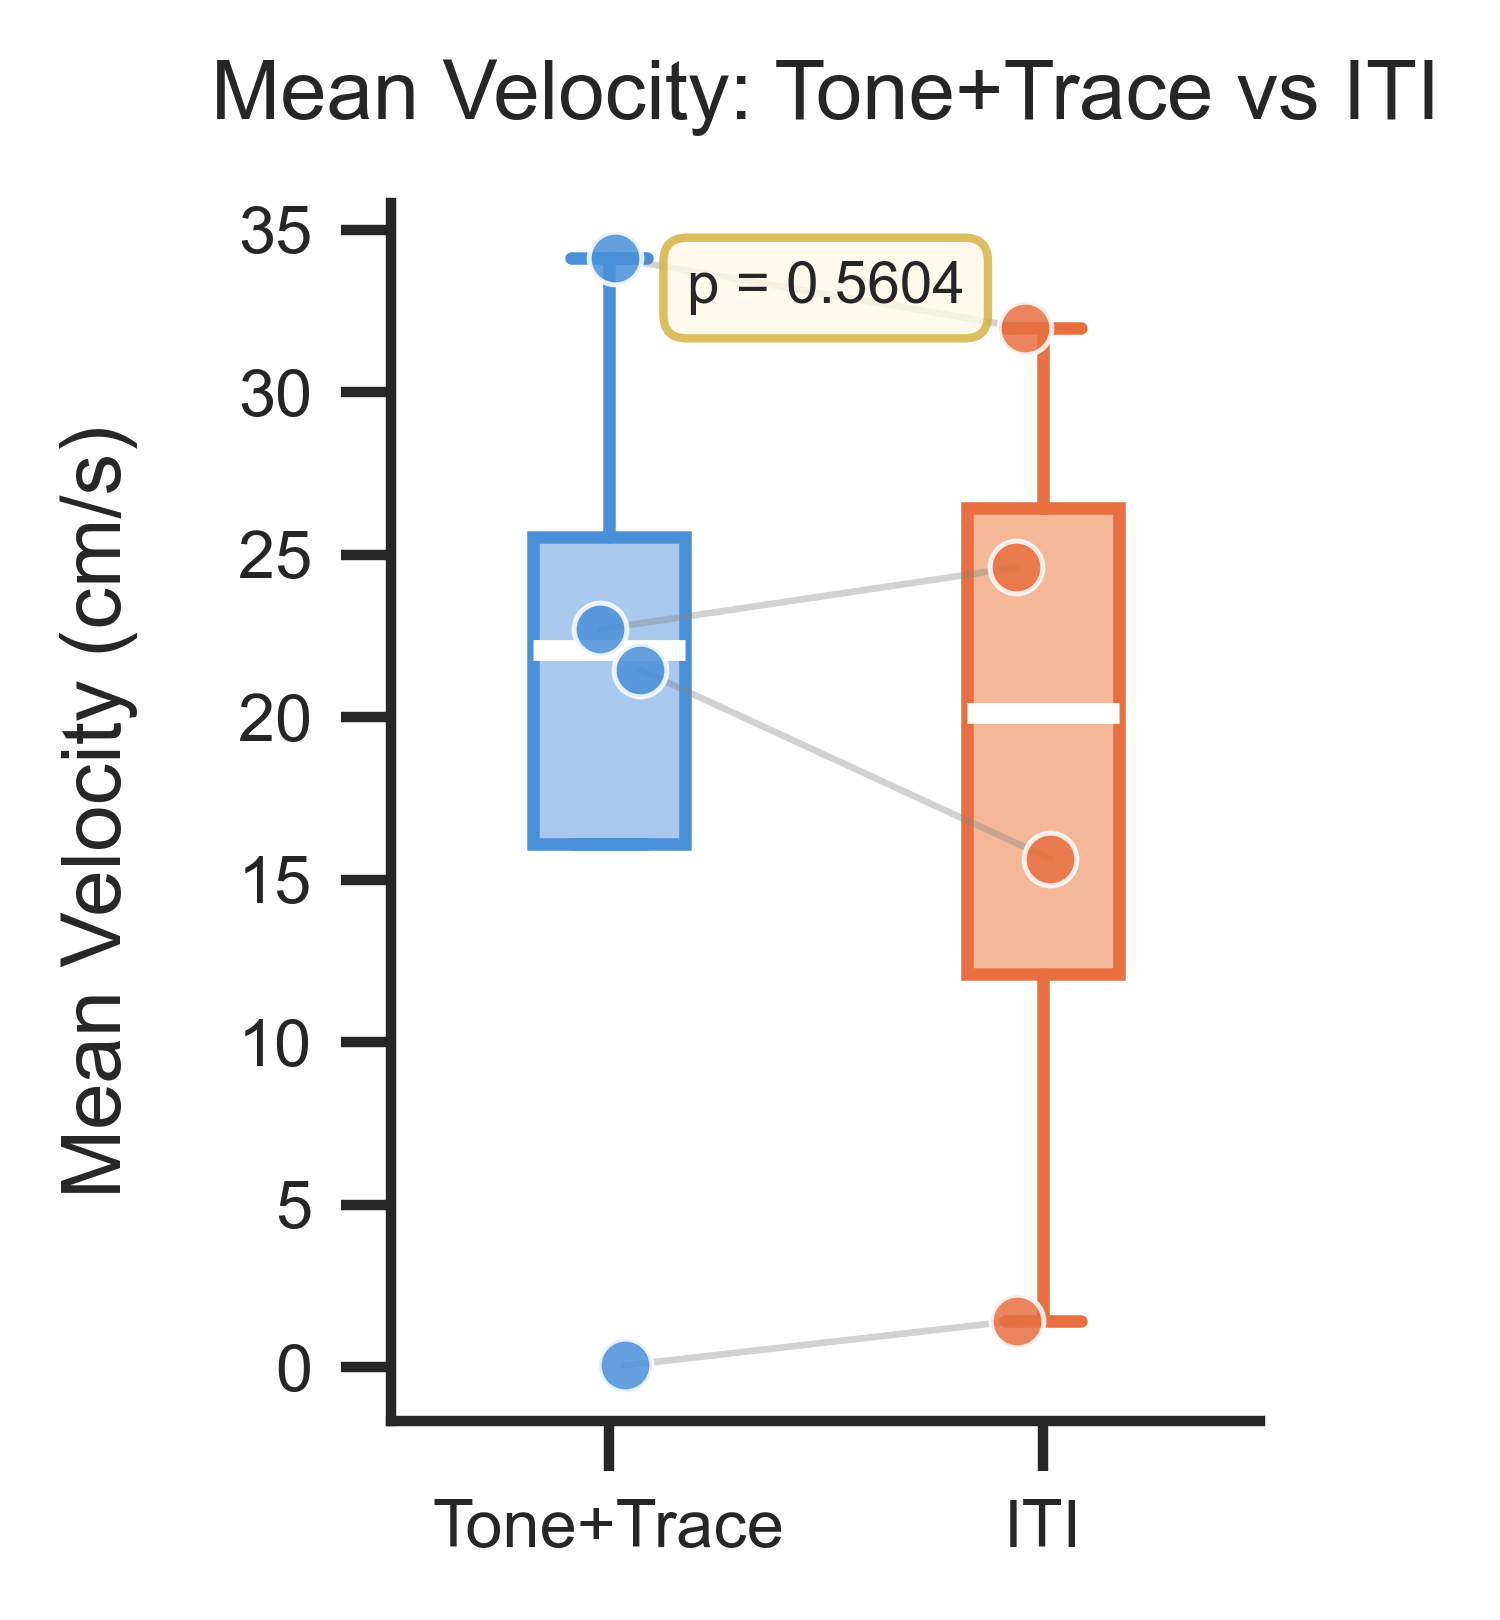

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv('/Users/suthardr/Desktop/recallB/processed/plots/epoch_summary_per_mouse.csv')

# Compute Tone+Trace (avg) per mouse
tone_trace = df[df['epoch'].isin(['Tone', 'Trace'])].groupby('mouse')['mean_velocity'].mean()
iti = df[df['epoch'] == 'ITI'].groupby('mouse')['mean_velocity'].first()

mice = sorted(tone_trace.index.intersection(iti.index))
tt_vals = np.array([tone_trace[m] for m in mice])
iti_vals = np.array([iti[m] for m in mice])

# Paired t-test
t_stat, p_val = stats.ttest_rel(tt_vals, iti_vals)
mean_diff = np.mean(tt_vals - iti_vals)
sem_diff = np.std(tt_vals - iti_vals, ddof=1) / np.sqrt(len(mice))

print(f"Paired t-test: Tone+Trace vs ITI")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Mean difference: {mean_diff:.4f} ± {sem_diff:.4f} cm/s")
print(f"n = {len(mice)} mice")

# Apply shock aesthetics
plt.rcParams.update({'font.size': 8})
sns.set(style="ticks", font="Arial")

fig, ax = plt.subplots(figsize=(3, 3.5), dpi=600)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

groups = ['Tone+Trace', 'ITI']
data = [tt_vals, iti_vals]
colors = ['#4A90D9', '#E87040']
light_colors = ['#A8C8EE', '#F4B899']

for gi, (vals, col, lcol) in enumerate(zip(data, colors, light_colors)):
    # Box plot
    ax.boxplot(vals, positions=[gi + 1], widths=0.35,
               patch_artist=True, showfliers=False, zorder=2,
               medianprops=dict(color='white', linewidth=2.5),
               boxprops=dict(facecolor=lcol, color=col, linewidth=1.5),
               whiskerprops=dict(color=col, linewidth=1.5),
               capprops=dict(color=col, linewidth=1.5))

    # Jittered individual points
    np.random.seed(42 + gi)
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), gi + 1) + jitter, vals,
               color=col, s=40, zorder=5, alpha=0.85,
               edgecolors='white', linewidths=0.6)

# RM lines
np.random.seed(42)
jitter1 = np.random.uniform(-0.08, 0.08, size=len(mice))
np.random.seed(43)
jitter2 = np.random.uniform(-0.08, 0.08, size=len(mice))

for i in range(len(mice)):
    ax.plot([1 + jitter1[i], 2 + jitter2[i]],
            [tt_vals[i], iti_vals[i]],
            color='gray', alpha=0.35, linewidth=0.8, zorder=3)

# Formatting
ax.set_xlim(0.5, 2.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(groups, fontsize=10, fontname='Arial')
ax.set_ylabel('Mean Velocity (cm/s)', fontsize=10, fontname='Arial', labelpad=12)
ax.set_title('Mean Velocity: Tone+Trace vs ITI', fontsize=10, fontname='Arial', pad=10)
ax.tick_params(axis='both', labelsize=8)

sns.despine(ax=ax)
plt.tight_layout(pad=3)

# Add significance indicator
if p_val < 0.05:
    sig_text = f"p = {p_val:.4f} *"
else:
    sig_text = f"p = {p_val:.4f}"

ax.text(1.5, ax.get_ylim()[1] * 0.95, sig_text,
        ha='center', va='top', fontsize=7, fontname='Arial',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9E6',
                  edgecolor='#D4AF37', linewidth=1, alpha=0.8))

# Optional save
plt.savefig('/Users/suthardr/Desktop/velocity_tone_trace_vs_iti.svg', dpi=600, bbox_inches='tight', format='svg')
plt.show()

Paired t-test: Tone+Trace vs ITI
t = -4.2602, p = 0.0028
n = 9 mice


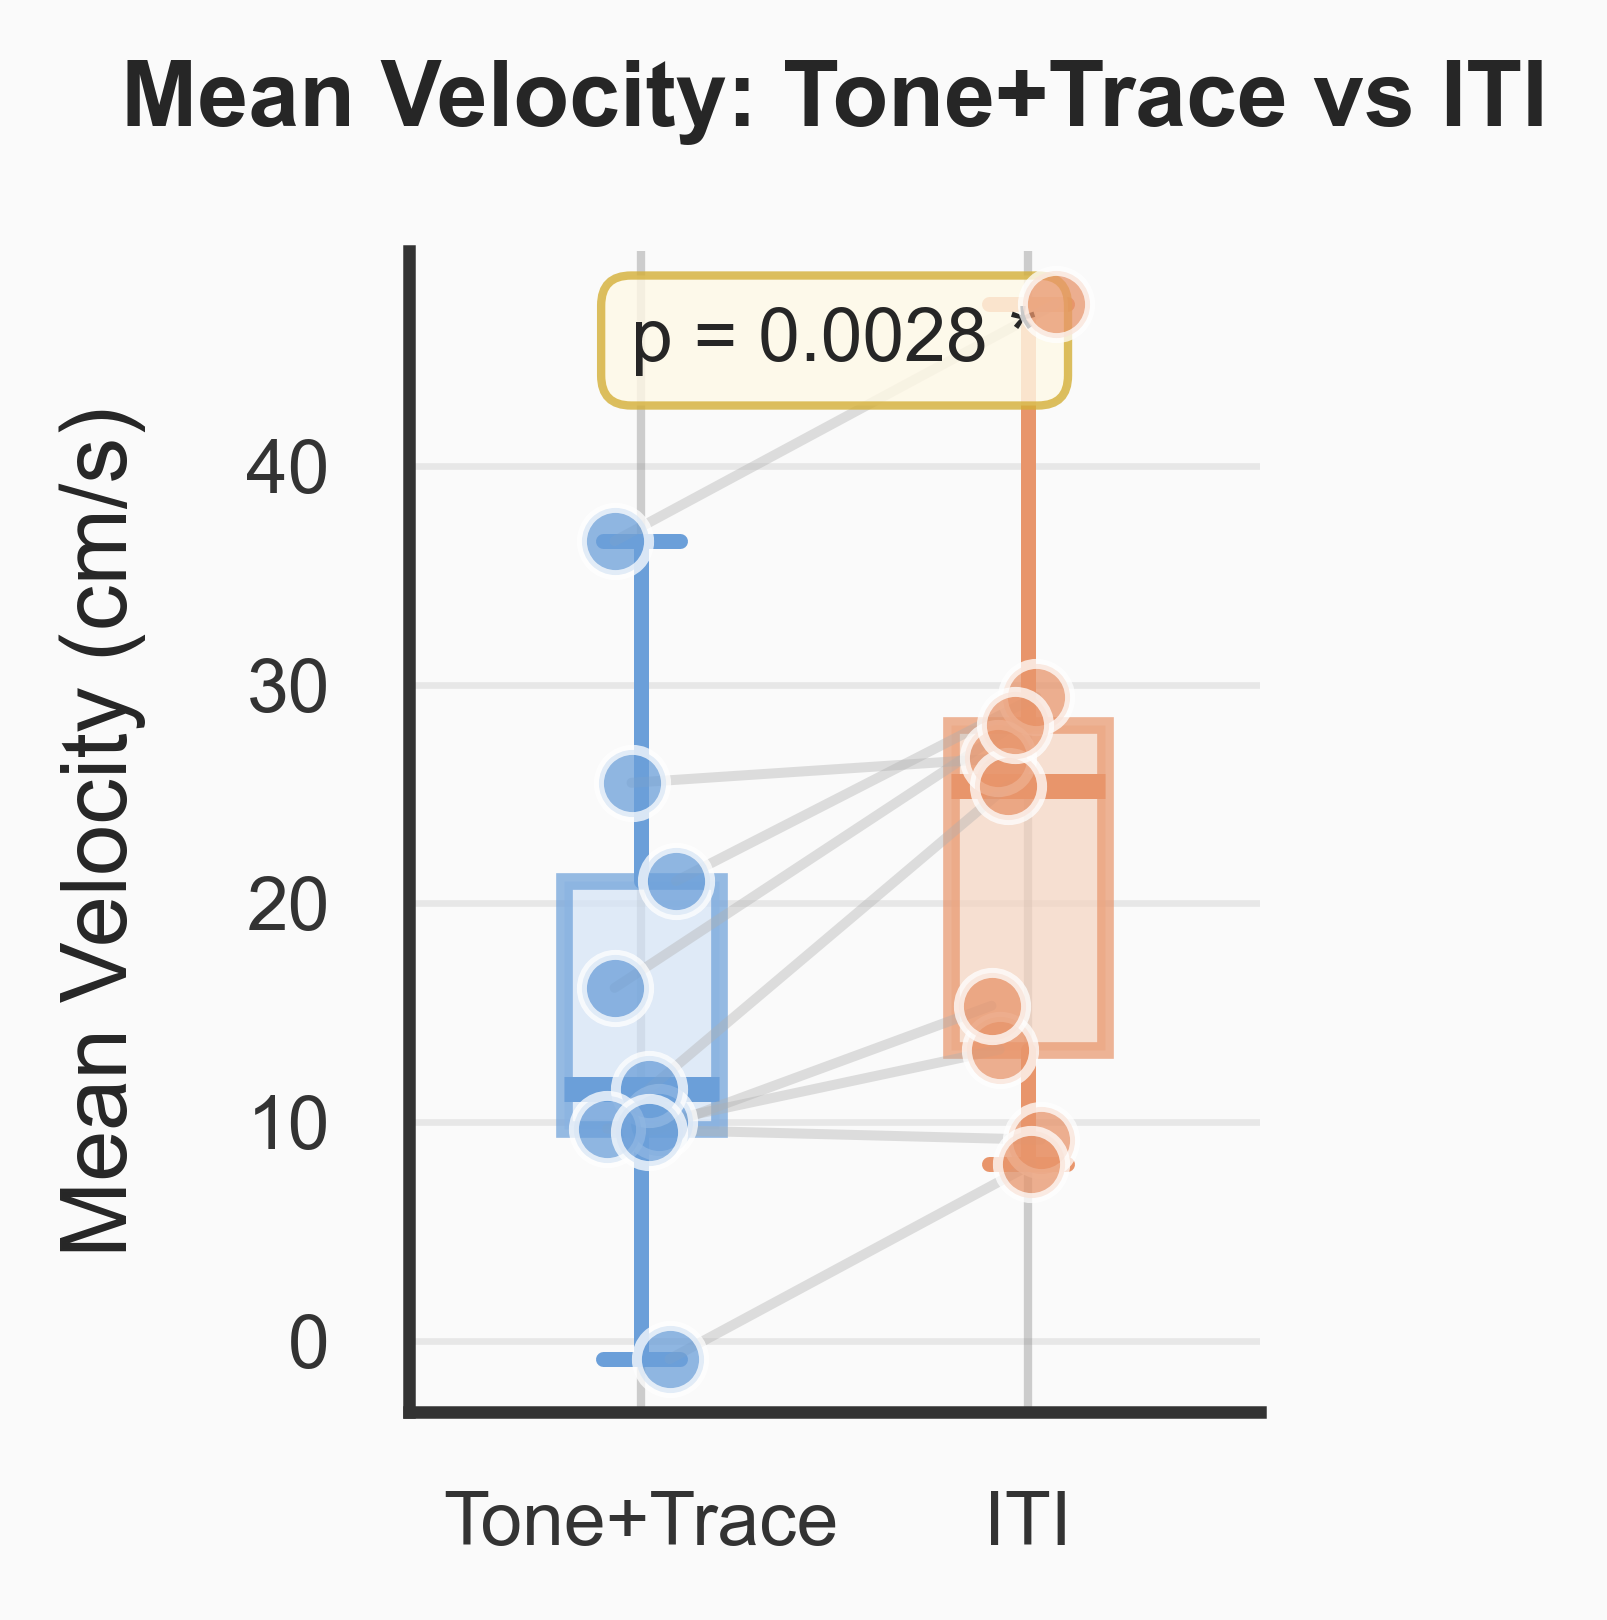

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv('/Users/suthardr/Desktop/epoch_summary_per_mouse_2p_recall.csv')

# Compute Tone+Trace (avg) per mouse
tone_trace = df[df['epoch'].isin(['Tone', 'Trace'])].groupby('mouse')['mean_velocity'].mean()
iti = df[df['epoch'] == 'ITI'].groupby('mouse')['mean_velocity'].first()

mice = sorted(tone_trace.index.intersection(iti.index))
tt_vals = np.array([tone_trace[m] for m in mice])
iti_vals = np.array([iti[m] for m in mice])

# Paired t-test
t_stat, p_val = stats.ttest_rel(tt_vals, iti_vals)

print(f"Paired t-test: Tone+Trace vs ITI")
print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"n = {len(mice)} mice")

# MAX CUTENESS AESTHETICS
plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
sns.set(style="whitegrid", font="Arial", palette="pastel")

fig, ax = plt.subplots(figsize=(3, 3.5), dpi=600)
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(axis='y', alpha=0.15, linewidth=0.8, linestyle='-', color='gray')
ax.set_axisbelow(True)

groups = ['Tone+Trace', 'ITI']
data = [tt_vals, iti_vals]
colors = ['#6B9FD9', '#E8956B']
light_colors = ['#D4E4F7', '#F5D4C0']

for gi, (vals, col, lcol) in enumerate(zip(data, colors, light_colors)):
    # Rounded box plot
    bp = ax.boxplot(vals, positions=[gi + 1], widths=0.4,
               patch_artist=True, showfliers=False, zorder=2,
               medianprops=dict(color=col, linewidth=3),
               boxprops=dict(facecolor=lcol, color=col, linewidth=2),
               whiskerprops=dict(color=col, linewidth=1.8),
               capprops=dict(color=col, linewidth=1.8))

    # Soften box edges
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    # Cuter jittered points
    np.random.seed(42 + gi)
    jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(np.full(len(vals), gi + 1) + jitter, vals,
               color=col, s=65, zorder=5, alpha=0.75,
               edgecolors='white', linewidths=1.2, rasterized=False)

# Cuter RM lines with slight curve
np.random.seed(42)
jitter1 = np.random.uniform(-0.1, 0.1, size=len(mice))
np.random.seed(43)
jitter2 = np.random.uniform(-0.1, 0.1, size=len(mice))

for i in range(len(mice)):
    ax.plot([1 + jitter1[i], 2 + jitter2[i]],
            [tt_vals[i], iti_vals[i]],
            color='#B0B0B0', alpha=0.4, linewidth=1.2, zorder=3, linestyle='-')

# Add significance indicator
if p_val < 0.05:
    sig_text = f"p = {p_val:.4f} *"
else:
    sig_text = f"p = {p_val:.4f}"

ax.text(1.5, ax.get_ylim()[1] * 0.95, sig_text,
        ha='center', va='top', fontsize=9, fontname='Arial',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9E6',
                  edgecolor='#D4AF37', linewidth=1, alpha=0.8))

# Formatting
ax.set_xlim(0.4, 2.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(groups, fontsize=11, fontname='Arial', fontweight='500')
ax.set_ylabel('Mean Velocity (cm/s)', fontsize=11, fontname='Arial',
              fontweight='500', labelpad=12)
ax.set_title('Mean Velocity: Tone+Trace vs ITI', fontsize=11, fontname='Arial',
             fontweight='600', pad=15)
ax.tick_params(axis='both', labelsize=9, colors='#333333')

# Cute spine styling
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
    ax.spines[spine].set_color('#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=3)
plt.show()

Paired t-test: Tone+Trace vs ITI
t = -4.2602, p = 0.0028
n = 9 mice


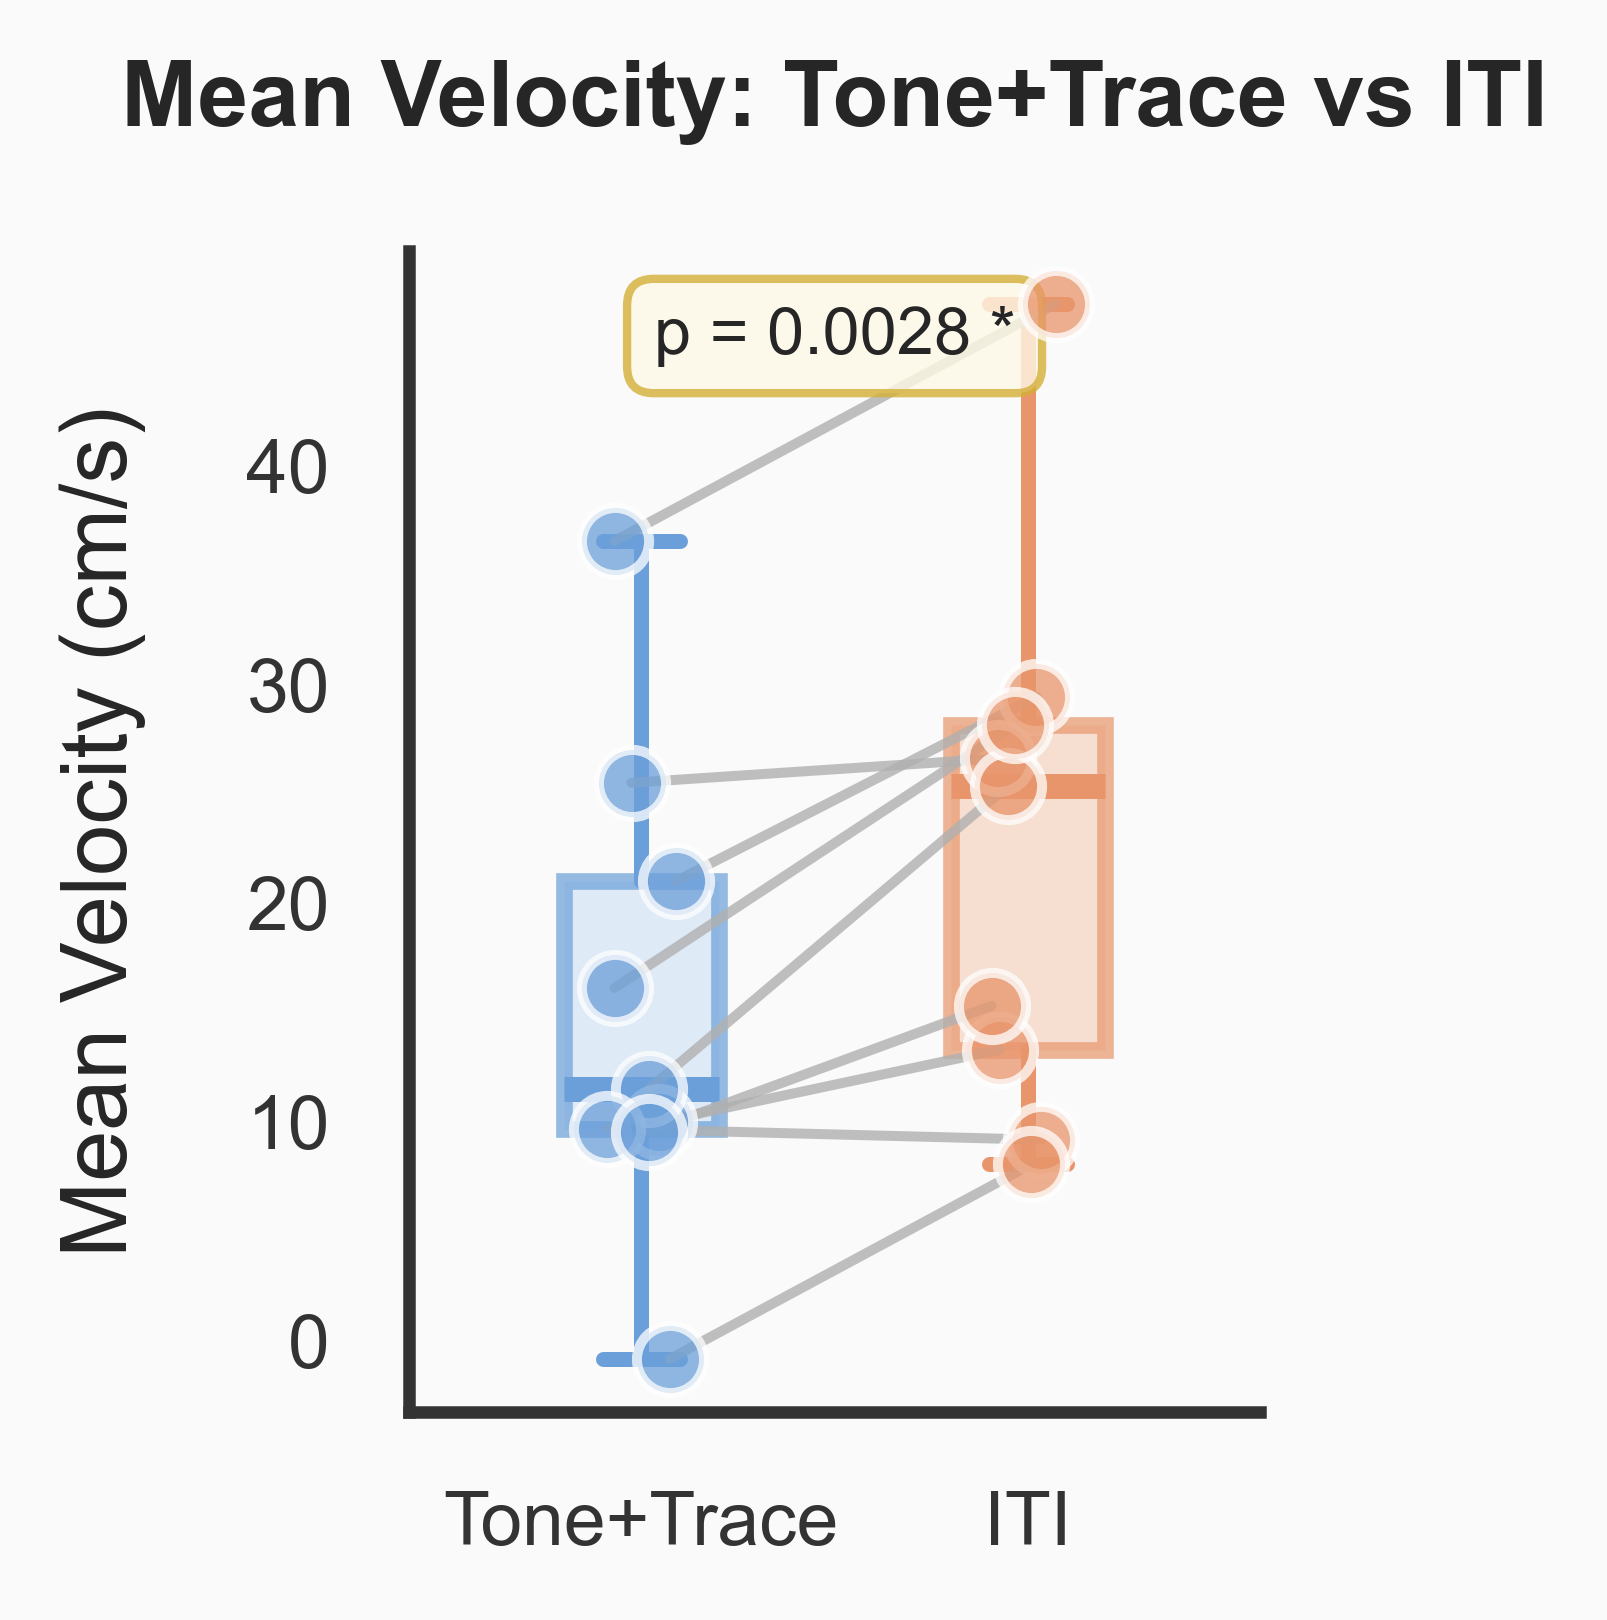

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_csv('/Users/suthardr/Desktop/epoch_summary_per_mouse_2p_recall.csv')

# Compute Tone+Trace (avg) per mouse
tone_trace = df[df['epoch'].isin(['Tone', 'Trace'])].groupby('mouse')['mean_velocity'].mean()
iti = df[df['epoch'] == 'ITI'].groupby('mouse')['mean_velocity'].first()

mice = sorted(tone_trace.index.intersection(iti.index))
tt_vals = np.array([tone_trace[m] for m in mice])
iti_vals = np.array([iti[m] for m in mice])

# Paired t-test
t_stat, p_val = stats.ttest_rel(tt_vals, iti_vals)

print(f"Paired t-test: Tone+Trace vs ITI")
print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"n = {len(mice)} mice")

# MAX CUTENESS AESTHETICS
plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
sns.set(style="white", font="Arial", palette="pastel")

fig, ax = plt.subplots(figsize=(3, 3.5), dpi=600)
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

groups = ['Tone+Trace', 'ITI']
data = [tt_vals, iti_vals]
colors = ['#6B9FD9', '#E8956B']
light_colors = ['#D4E4F7', '#F5D4C0']

for gi, (vals, col, lcol) in enumerate(zip(data, colors, light_colors)):
    # Rounded box plot
    bp = ax.boxplot(vals, positions=[gi + 1], widths=0.4,
               patch_artist=True, showfliers=False, zorder=2,
               medianprops=dict(color=col, linewidth=3),
               boxprops=dict(facecolor=lcol, color=col, linewidth=2),
               whiskerprops=dict(color=col, linewidth=1.8),
               capprops=dict(color=col, linewidth=1.8))

    # Soften box edges
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    # Cuter jittered points
    np.random.seed(42 + gi)
    jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(np.full(len(vals), gi + 1) + jitter, vals,
               color=col, s=65, zorder=5, alpha=0.75,
               edgecolors='white', linewidths=1.2, rasterized=False)

# Cuter RM lines with slight curve
np.random.seed(42)
jitter1 = np.random.uniform(-0.1, 0.1, size=len(mice))
np.random.seed(43)
jitter2 = np.random.uniform(-0.1, 0.1, size=len(mice))

for i in range(len(mice)):
    ax.plot([1 + jitter1[i], 2 + jitter2[i]],
            [tt_vals[i], iti_vals[i]],
            color='#B0B0B0', alpha=0.8, linewidth=1.2, zorder=3, linestyle='-')

# Add significance indicator
if p_val < 0.05:
    sig_text = f"p = {p_val:.4f} *"
else:
    sig_text = f"p = {p_val:.4f}"

ax.text(1.5, ax.get_ylim()[1] * 0.95, sig_text,
        ha='center', va='top', fontsize=8, fontname='Arial',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9E6',
                  edgecolor='#D4AF37', linewidth=1, alpha=0.8))

# Formatting
ax.set_xlim(0.4, 2.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(groups, fontsize=11, fontname='Arial', fontweight='500')
ax.set_ylabel('Mean Velocity (cm/s)', fontsize=11, fontname='Arial',
              fontweight='500', labelpad=12)
ax.set_title('Mean Velocity: Tone+Trace vs ITI', fontsize=11, fontname='Arial',
             fontweight='600', pad=15)
ax.tick_params(axis='both', labelsize=9, colors='#333333')

# Cute spine styling
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
    ax.spines[spine].set_color('#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('/Users/suthardr/Desktop/velocity_tone_trace_vs_iti.svg', dpi=600, bbox_inches='tight', format='svg')
plt.tight_layout(pad=3)
plt.show()